In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

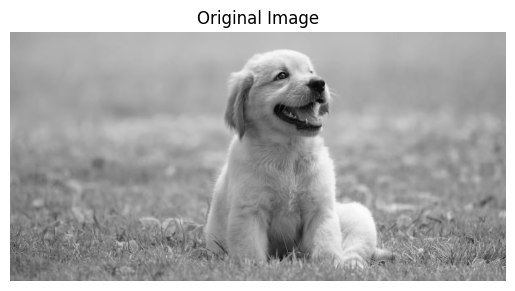

In [2]:
image = cv2.imread("../Data/Dog.jpg", cv2.IMREAD_GRAYSCALE)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

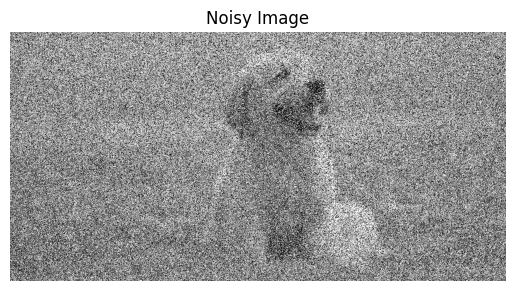

In [3]:
#Add Salt and pepper Noise
def add_salt_pepper_noise(image, probability=0.1):
  noisy = image.copy()
  random_matrix = np.random.rand(*image.shape)
  noisy[random_matrix < probability / 2] = 0
  noisy[random_matrix > 1 - (probability / 2)] = 255
  return noisy

noisy_image = add_salt_pepper_noise(image, probability=0.5)

plt.imshow(noisy_image, cmap="gray")
plt.title("Noisy Image")
plt.axis("off")
plt.show()

In [ ]:
# Median Filter Function
def median_filter(image, kernel_size=3, stride=1):
  h, w = image.shape
  pad = kernel_size // 2
  padded = np.pad(image, pad, mode='reflect')
  
  out_h = (h - kernel_size + 2 * pad) // stride + 1
  out_w = (w - kernel_size + 2 * pad) // stride + 1
  
  output = np.zeros((out_h, out_w), dtype=image.dtype)
  
  for i in range(out_h):
    for j in range(out_w):
      window = padded[i*stride : i*stride + kernel_size, j*stride : j*stride + kernel_size]
      output[i, j] = np.median(window)
      
  return output